Total samples: 13787
Median sum: 593.0
Group 1 (≤ median): 6914 (50.15%)
Group 2 (> median): 6873 (49.85%)


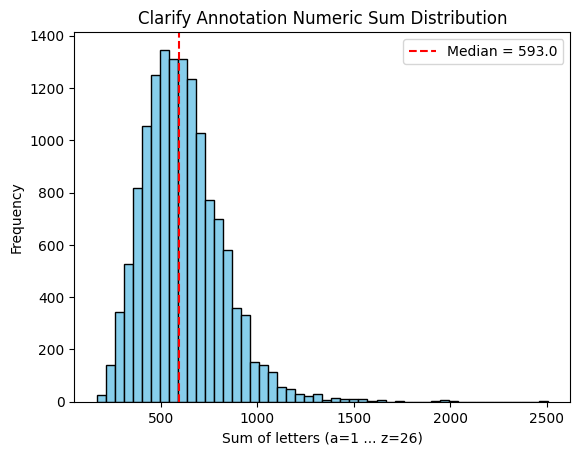

In [1]:
# 📓 Clarify Annotation Numeric Sum Analysis

import json
import numpy as np
import matplotlib.pyplot as plt

# --- Load data ---
annotations_path = "annotations_v2.jsonl"

def text_to_sum(s: str) -> int:
    """Convert text to numeric sum (a=1, b=2, ..., z=26)."""
    total = 0
    for ch in s.lower():
        if 'a' <= ch <= 'z':
            total += ord(ch) - ord('a') + 1
    return total

sums = []
with open(annotations_path, "r", encoding="utf-8") as f:
    for line in f:
        ann = json.loads(line)
        if "clarify_annotation" in ann:
            text = ann["clarify_annotation"].strip()
            if text:
                sums.append(text_to_sum(text))

sums = np.array(sums)

# --- Split into two groups: below vs above median ---
median_val = np.median(sums)
group_low = sums[sums <= median_val]
group_high = sums[sums > median_val]

print(f"Total samples: {len(sums)}")
print(f"Median sum: {median_val}")
print(f"Group 1 (≤ median): {len(group_low)} ({len(group_low)/len(sums):.2%})")
print(f"Group 2 (> median): {len(group_high)} ({len(group_high)/len(sums):.2%})")

# --- Plot histogram ---
plt.hist(sums, bins=50, color="skyblue", edgecolor="black")
plt.axvline(median_val, color="red", linestyle="--", label=f"Median = {median_val}")
plt.title("Clarify Annotation Numeric Sum Distribution")
plt.xlabel("Sum of letters (a=1 ... z=26)")
plt.ylabel("Frequency")
plt.legend()
plt.show()
